# DP-GAN HeatMap Analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



SINGLE-IMAGE FREQUENCY REPORT

Real image energy:
  LOW: 1727.4038
  MID: 1486.2756
 HIGH: 1769.1711

Fake image energy:
  LOW: 1742.8169
  MID: 1444.4971
 HIGH: 2414.4905

Difference (Fake - Real):
  LOW: 15.4131
  MID: -41.7786
 HIGH: 645.3193


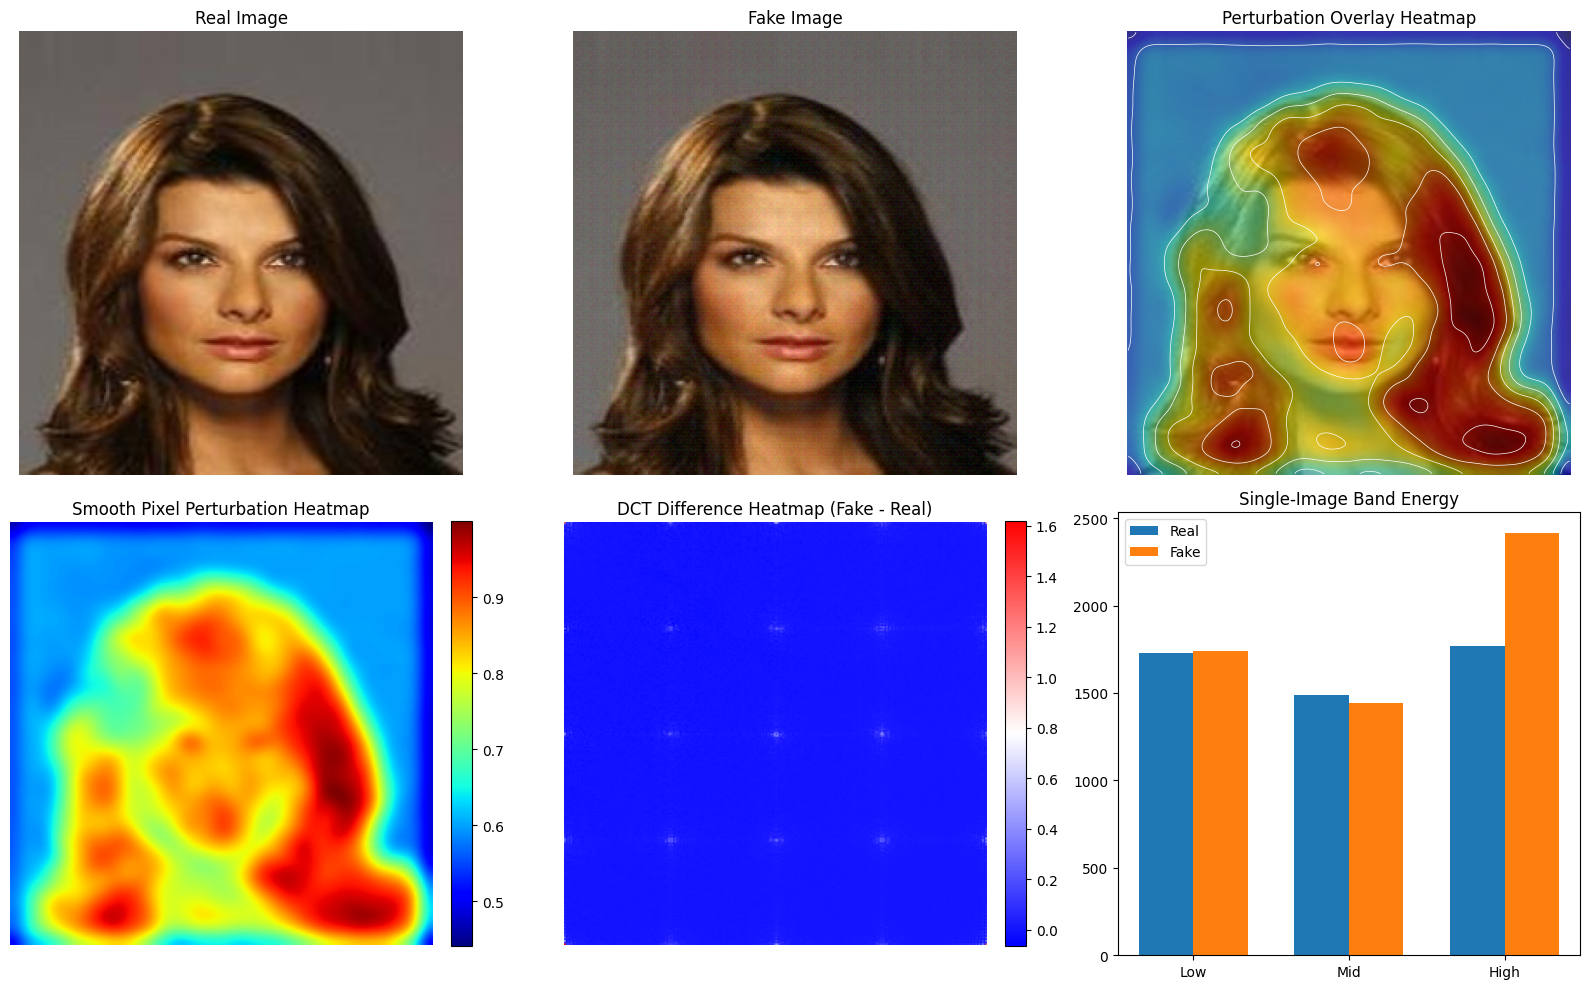


Single real path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data_Final/000034.jpg
Single fake path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED_Final/000034_fake.png


In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct
from scipy.ndimage import gaussian_filter
from tqdm import tqdm


# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data_Final/000034.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED_Final/000034_fake.png"  # change this
IMG_SIZE = 256

LOW_RATIO = 0.10
MID_RATIO = 0.30
HEATMAP_SIGMA = 6

# =========================================================
# HELPERS
# =========================================================
def load_img(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def compute_dct_band_energy(img, low_ratio=0.10, mid_ratio=0.30):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = dct2(img[:, :, c])
        coeff = np.abs(coeff)

        h, w = coeff.shape
        low_cut = max(1, int(h * low_ratio))
        mid_cut = max(low_cut + 1, int(h * mid_ratio))

        # LOW
        low = coeff[:low_cut, :low_cut].sum()

        # MID
        mid_mask = np.zeros_like(coeff, dtype=bool)
        mid_mask[:mid_cut, :mid_cut] = True
        mid_mask[:low_cut, :low_cut] = False
        mid = coeff[mid_mask].sum()

        # HIGH
        high_mask = np.ones_like(coeff, dtype=bool)
        high_mask[:mid_cut, :mid_cut] = False
        high = coeff[high_mask].sum()

        energies["low"] += low
        energies["mid"] += mid
        energies["high"] += high

    return energies

def get_sorted_image_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

def process_folder(folder, low_ratio=0.10, mid_ratio=0.30):
    files = get_sorted_image_files(folder)

    total = {"low": 0.0, "mid": 0.0, "high": 0.0}
    count = 0

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)

        try:
            img = load_img(path, IMG_SIZE)
            energy = compute_dct_band_energy(img, low_ratio, mid_ratio)

            for k in total:
                total[k] += energy[k]
            count += 1

        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if count == 0:
        raise ValueError(f"No valid images found in {folder}")

    avg = {k: total[k] / count for k in total}
    return avg

def dct_rgb(img):
    out = []
    for c in range(3):
        out.append(dct2(img[:, :, c]))
    return np.stack(out, axis=-1)


# =========================================================
# 2) SINGLE-IMAGE REPORT (MANUAL PATH INPUT)
# =========================================================
real_img = load_img(single_real_path, IMG_SIZE)
fake_img = load_img(single_fake_path, IMG_SIZE)

real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)
single_diff = {k: fake_energy[k] - real_energy[k] for k in real_energy}

print("\n" + "="*60)
print("SINGLE-IMAGE FREQUENCY REPORT")
print("="*60)

print("\nReal image energy:")
for k, v in real_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake image energy:")
for k, v in fake_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in single_diff.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 3) HEATMAPS FOR THE SAME SINGLE IMAGE
# =========================================================
delta = np.abs(fake_img - real_img)
delta_gray = delta.mean(axis=2)
smooth_map = gaussian_filter(delta_gray, sigma=HEATMAP_SIGMA)
smooth_map = smooth_map / (smooth_map.max() + 1e-8)

real_dct = dct_rgb(real_img)
fake_dct = dct_rgb(fake_img)

real_dct_mag = np.abs(real_dct).mean(axis=2)
fake_dct_mag = np.abs(fake_dct).mean(axis=2)
dct_diff = fake_dct_mag - real_dct_mag

# =========================================================
# 4) PLOTS
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(real_img)
axes[0, 0].set_title("Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fake_img)
axes[0, 1].set_title("Fake Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(real_img)
axes[0, 2].imshow(smooth_map, cmap="jet", alpha=0.5)
axes[0, 2].contour(smooth_map, colors="white", linewidths=0.5)
axes[0, 2].set_title("Perturbation Overlay Heatmap")
axes[0, 2].axis("off")

im1 = axes[1, 0].imshow(smooth_map, cmap="jet")
axes[1, 0].set_title("Smooth Pixel Perturbation Heatmap")
axes[1, 0].axis("off")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(dct_diff, cmap="bwr")
axes[1, 1].set_title("DCT Difference Heatmap (Fake - Real)")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

bands = ["Low", "Mid", "High"]
real_vals = [real_energy["low"], real_energy["mid"], real_energy["high"]]
fake_vals = [fake_energy["low"], fake_energy["mid"], fake_energy["high"]]

x = np.arange(len(bands))
width = 0.35

axes[1, 2].bar(x - width/2, real_vals, width, label="Real")
axes[1, 2].bar(x + width/2, fake_vals, width, label="Fake")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(bands)
axes[1, 2].set_title("Single-Image Band Energy")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\nSingle real path :", single_real_path)
print("Single fake path :", single_fake_path)


SINGLE-IMAGE FREQUENCY REPORT

Real image energy:
  LOW: 1727.4038
  MID: 1486.2756
 HIGH: 1769.1711

Fake image energy:
  LOW: 1701.6107
  MID: 1430.0266
 HIGH: 2203.4299

Difference (Fake - Real):
  LOW: -25.7931
  MID: -56.2490
 HIGH: 434.2588


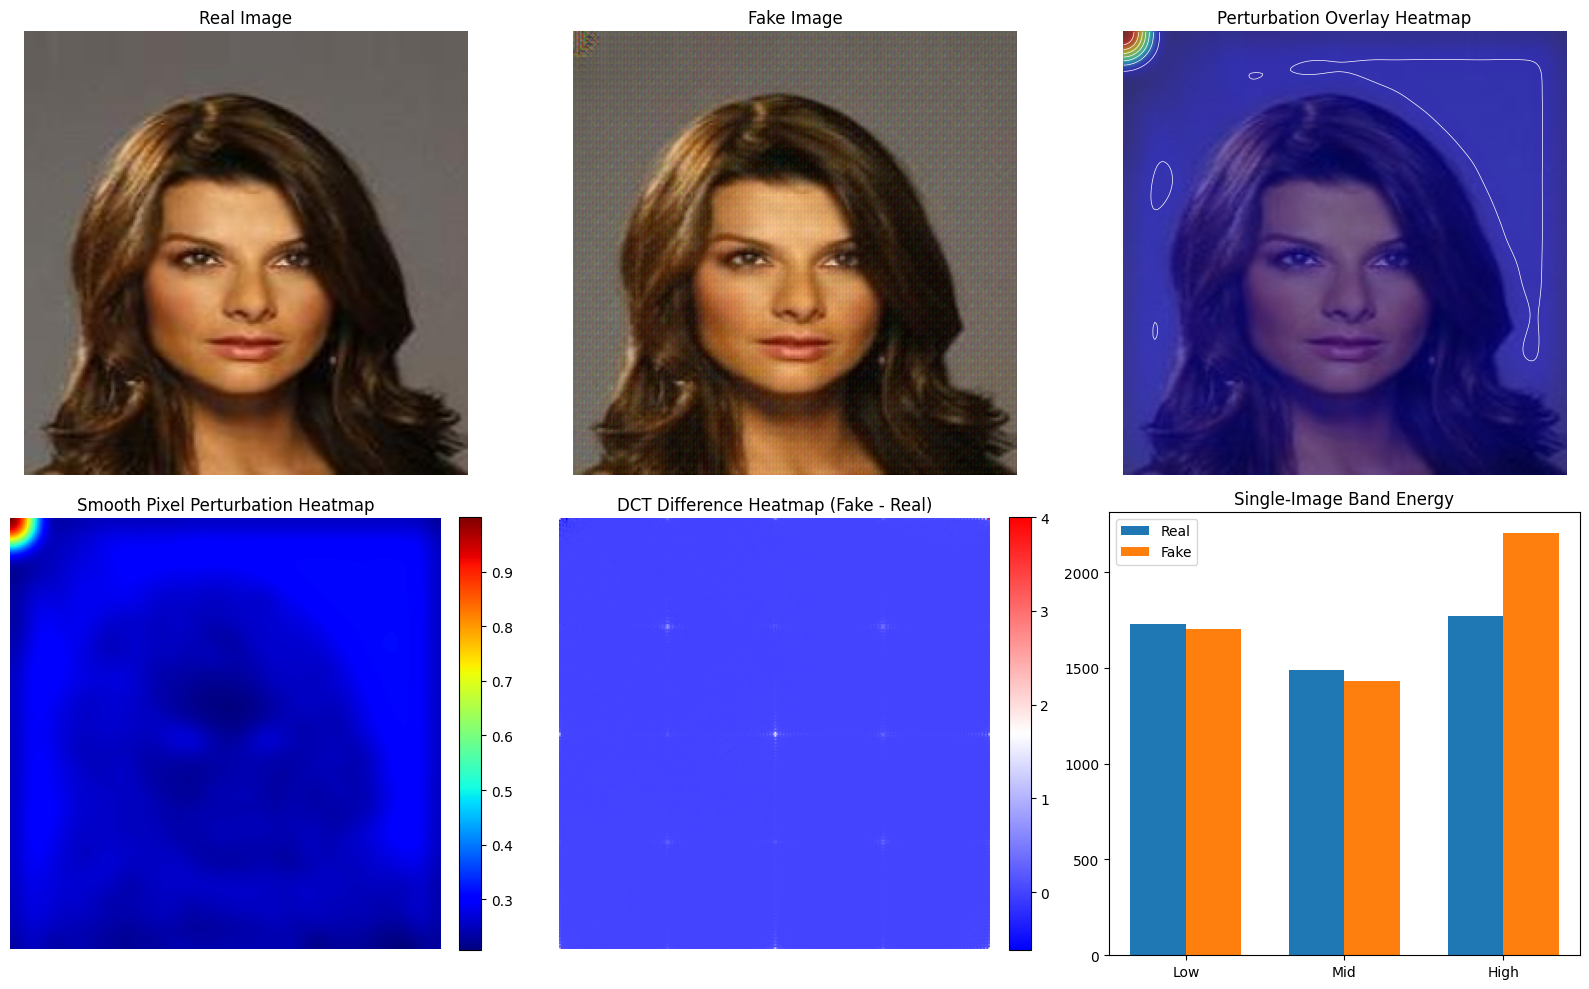


Single real path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data_Final/000034.jpg
Single fake path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_SPOOFED_Final/000034_fake.png


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct
from scipy.ndimage import gaussian_filter
from tqdm import tqdm


# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data_Final/000034.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_SPOOFED_Final/000034_fake.png"  # change this
IMG_SIZE = 256

LOW_RATIO = 0.10
MID_RATIO = 0.30
HEATMAP_SIGMA = 6

# =========================================================
# HELPERS
# =========================================================
def load_img(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def compute_dct_band_energy(img, low_ratio=0.10, mid_ratio=0.30):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = dct2(img[:, :, c])
        coeff = np.abs(coeff)

        h, w = coeff.shape
        low_cut = max(1, int(h * low_ratio))
        mid_cut = max(low_cut + 1, int(h * mid_ratio))

        # LOW
        low = coeff[:low_cut, :low_cut].sum()

        # MID
        mid_mask = np.zeros_like(coeff, dtype=bool)
        mid_mask[:mid_cut, :mid_cut] = True
        mid_mask[:low_cut, :low_cut] = False
        mid = coeff[mid_mask].sum()

        # HIGH
        high_mask = np.ones_like(coeff, dtype=bool)
        high_mask[:mid_cut, :mid_cut] = False
        high = coeff[high_mask].sum()

        energies["low"] += low
        energies["mid"] += mid
        energies["high"] += high

    return energies

def get_sorted_image_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

def process_folder(folder, low_ratio=0.10, mid_ratio=0.30):
    files = get_sorted_image_files(folder)

    total = {"low": 0.0, "mid": 0.0, "high": 0.0}
    count = 0

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)

        try:
            img = load_img(path, IMG_SIZE)
            energy = compute_dct_band_energy(img, low_ratio, mid_ratio)

            for k in total:
                total[k] += energy[k]
            count += 1

        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if count == 0:
        raise ValueError(f"No valid images found in {folder}")

    avg = {k: total[k] / count for k in total}
    return avg

def dct_rgb(img):
    out = []
    for c in range(3):
        out.append(dct2(img[:, :, c]))
    return np.stack(out, axis=-1)


# =========================================================
# 2) SINGLE-IMAGE REPORT (MANUAL PATH INPUT)
# =========================================================
real_img = load_img(single_real_path, IMG_SIZE)
fake_img = load_img(single_fake_path, IMG_SIZE)

real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)
single_diff = {k: fake_energy[k] - real_energy[k] for k in real_energy}

print("\n" + "="*60)
print("SINGLE-IMAGE FREQUENCY REPORT")
print("="*60)

print("\nReal image energy:")
for k, v in real_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake image energy:")
for k, v in fake_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in single_diff.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 3) HEATMAPS FOR THE SAME SINGLE IMAGE
# =========================================================
delta = np.abs(fake_img - real_img)
delta_gray = delta.mean(axis=2)
smooth_map = gaussian_filter(delta_gray, sigma=HEATMAP_SIGMA)
smooth_map = smooth_map / (smooth_map.max() + 1e-8)

real_dct = dct_rgb(real_img)
fake_dct = dct_rgb(fake_img)

real_dct_mag = np.abs(real_dct).mean(axis=2)
fake_dct_mag = np.abs(fake_dct).mean(axis=2)
dct_diff = fake_dct_mag - real_dct_mag

# =========================================================
# 4) PLOTS
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(real_img)
axes[0, 0].set_title("Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fake_img)
axes[0, 1].set_title("Fake Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(real_img)
axes[0, 2].imshow(smooth_map, cmap="jet", alpha=0.5)
axes[0, 2].contour(smooth_map, colors="white", linewidths=0.5)
axes[0, 2].set_title("Perturbation Overlay Heatmap")
axes[0, 2].axis("off")

im1 = axes[1, 0].imshow(smooth_map, cmap="jet")
axes[1, 0].set_title("Smooth Pixel Perturbation Heatmap")
axes[1, 0].axis("off")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(dct_diff, cmap="bwr")
axes[1, 1].set_title("DCT Difference Heatmap (Fake - Real)")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

bands = ["Low", "Mid", "High"]
real_vals = [real_energy["low"], real_energy["mid"], real_energy["high"]]
fake_vals = [fake_energy["low"], fake_energy["mid"], fake_energy["high"]]

x = np.arange(len(bands))
width = 0.35

axes[1, 2].bar(x - width/2, real_vals, width, label="Real")
axes[1, 2].bar(x + width/2, fake_vals, width, label="Fake")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(bands)
axes[1, 2].set_title("Single-Image Band Energy")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\nSingle real path :", single_real_path)
print("Single fake path :", single_fake_path)


SINGLE-IMAGE FREQUENCY REPORT

Real image energy:
  LOW: 2489.8694
  MID: 1860.0643
 HIGH: 1885.7920

Fake image energy:
  LOW: 2485.8706
  MID: 2034.6763
 HIGH: 2451.3411

Difference (Fake - Real):
  LOW: -3.9988
  MID: 174.6119
 HIGH: 565.5491


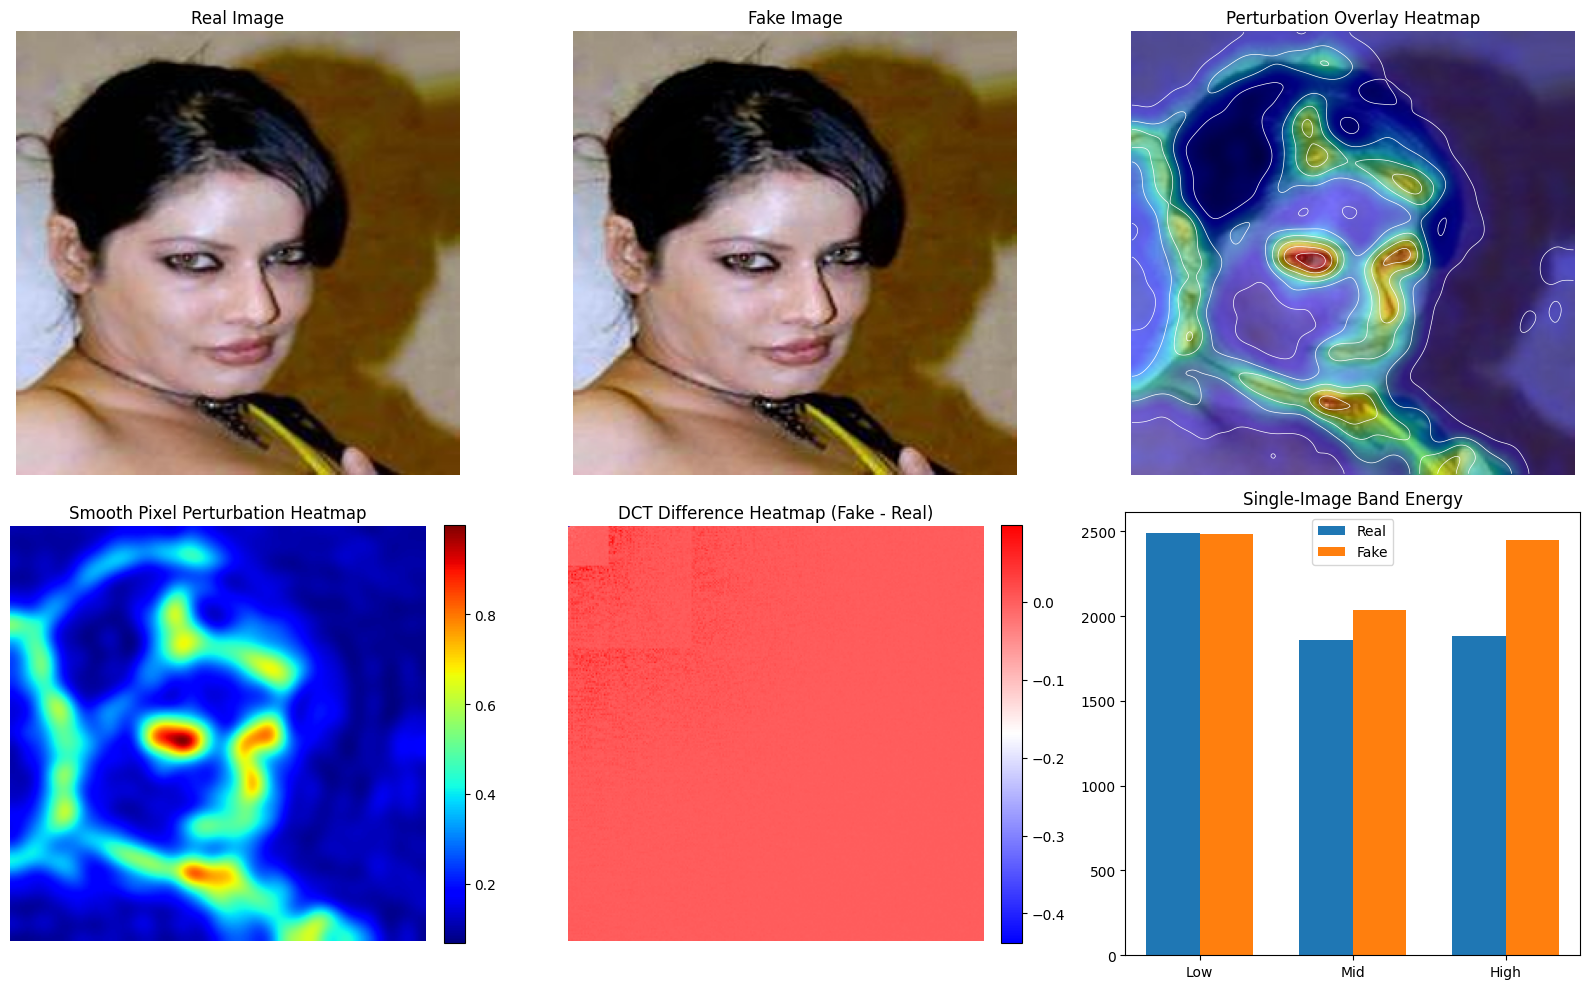


Single real path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data/027011.jpg
Single fake path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data/027011_fake.png


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct
from scipy.ndimage import gaussian_filter
from tqdm import tqdm


# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data/027011.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data/027011_fake.png"  # change this
IMG_SIZE = 256

LOW_RATIO = 0.10
MID_RATIO = 0.30
HEATMAP_SIGMA = 6

# =========================================================
# HELPERS
# =========================================================
def load_img(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def compute_dct_band_energy(img, low_ratio=0.10, mid_ratio=0.30):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = dct2(img[:, :, c])
        coeff = np.abs(coeff)

        h, w = coeff.shape
        low_cut = max(1, int(h * low_ratio))
        mid_cut = max(low_cut + 1, int(h * mid_ratio))

        # LOW
        low = coeff[:low_cut, :low_cut].sum()

        # MID
        mid_mask = np.zeros_like(coeff, dtype=bool)
        mid_mask[:mid_cut, :mid_cut] = True
        mid_mask[:low_cut, :low_cut] = False
        mid = coeff[mid_mask].sum()

        # HIGH
        high_mask = np.ones_like(coeff, dtype=bool)
        high_mask[:mid_cut, :mid_cut] = False
        high = coeff[high_mask].sum()

        energies["low"] += low
        energies["mid"] += mid
        energies["high"] += high

    return energies

def get_sorted_image_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

def process_folder(folder, low_ratio=0.10, mid_ratio=0.30):
    files = get_sorted_image_files(folder)

    total = {"low": 0.0, "mid": 0.0, "high": 0.0}
    count = 0

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)

        try:
            img = load_img(path, IMG_SIZE)
            energy = compute_dct_band_energy(img, low_ratio, mid_ratio)

            for k in total:
                total[k] += energy[k]
            count += 1

        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if count == 0:
        raise ValueError(f"No valid images found in {folder}")

    avg = {k: total[k] / count for k in total}
    return avg

def dct_rgb(img):
    out = []
    for c in range(3):
        out.append(dct2(img[:, :, c]))
    return np.stack(out, axis=-1)


# =========================================================
# 2) SINGLE-IMAGE REPORT (MANUAL PATH INPUT)
# =========================================================
real_img = load_img(single_real_path, IMG_SIZE)
fake_img = load_img(single_fake_path, IMG_SIZE)

real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)
single_diff = {k: fake_energy[k] - real_energy[k] for k in real_energy}

print("\n" + "="*60)
print("SINGLE-IMAGE FREQUENCY REPORT")
print("="*60)

print("\nReal image energy:")
for k, v in real_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake image energy:")
for k, v in fake_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in single_diff.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 3) HEATMAPS FOR THE SAME SINGLE IMAGE
# =========================================================
delta = np.abs(fake_img - real_img)
delta_gray = delta.mean(axis=2)
smooth_map = gaussian_filter(delta_gray, sigma=HEATMAP_SIGMA)
smooth_map = smooth_map / (smooth_map.max() + 1e-8)

real_dct = dct_rgb(real_img)
fake_dct = dct_rgb(fake_img)

real_dct_mag = np.abs(real_dct).mean(axis=2)
fake_dct_mag = np.abs(fake_dct).mean(axis=2)
dct_diff = fake_dct_mag - real_dct_mag

# =========================================================
# 4) PLOTS
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(real_img)
axes[0, 0].set_title("Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fake_img)
axes[0, 1].set_title("Fake Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(real_img)
axes[0, 2].imshow(smooth_map, cmap="jet", alpha=0.5)
axes[0, 2].contour(smooth_map, colors="white", linewidths=0.5)
axes[0, 2].set_title("Perturbation Overlay Heatmap")
axes[0, 2].axis("off")

im1 = axes[1, 0].imshow(smooth_map, cmap="jet")
axes[1, 0].set_title("Smooth Pixel Perturbation Heatmap")
axes[1, 0].axis("off")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(dct_diff, cmap="bwr")
axes[1, 1].set_title("DCT Difference Heatmap (Fake - Real)")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

bands = ["Low", "Mid", "High"]
real_vals = [real_energy["low"], real_energy["mid"], real_energy["high"]]
fake_vals = [fake_energy["low"], fake_energy["mid"], fake_energy["high"]]

x = np.arange(len(bands))
width = 0.35

axes[1, 2].bar(x - width/2, real_vals, width, label="Real")
axes[1, 2].bar(x + width/2, fake_vals, width, label="Fake")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(bands)
axes[1, 2].set_title("Single-Image Band Energy")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\nSingle real path :", single_real_path)
print("Single fake path :", single_fake_path)

In [18]:
import os

# =========================================================
# TWO FAKE FOLDERS
# =========================================================
fake_folder_1 = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED_Final"
fake_folder_2 = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_SPOOFED_Final"


# =========================================================
# VALID IMAGE EXTENSIONS
# =========================================================
valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".webp")


# =========================================================
# LOAD FILENAMES
# =========================================================
files_1 = {
    f for f in os.listdir(fake_folder_1)
    if f.lower().endswith(valid_extensions)
}

files_2 = {
    f for f in os.listdir(fake_folder_2)
    if f.lower().endswith(valid_extensions)
}


# =========================================================
# SAME FILE NAMES
# =========================================================
same_files = sorted(files_1.intersection(files_2))

# files only in folder 1
only_in_folder1 = sorted(files_1 - files_2)

# files only in folder 2
only_in_folder2 = sorted(files_2 - files_1)


# =========================================================
# REPORT
# =========================================================
print("=" * 60)
print("FILE MATCH REPORT")
print("=" * 60)

print(f"\nTotal files in Folder 1: {len(files_1)}")
print(f"Total files in Folder 2: {len(files_2)}")

print(f"\nMatched filenames: {len(same_files)}")

print(f"\nOnly in Folder 1: {len(only_in_folder1)}")
print(f"Only in Folder 2: {len(only_in_folder2)}")


# =========================================================
# PRINT MATCHED FILES
# =========================================================
print("\n" + "=" * 60)
print("MATCHED FILES")
print("=" * 60)

for f in same_files:
    print(f)


# =========================================================
# OPTIONAL
# PRINT UNMATCHED FILES
# =========================================================
print("\n" + "=" * 60)
print("ONLY IN FOLDER 1")
print("=" * 60)

for f in only_in_folder1[:20]:
    print(f)

print("\n" + "=" * 60)
print("ONLY IN FOLDER 2")
print("=" * 60)

for f in only_in_folder2[:20]:
    print(f)

FILE MATCH REPORT

Total files in Folder 1: 4000
Total files in Folder 2: 4004

Matched filenames: 1239

Only in Folder 1: 2761
Only in Folder 2: 2765

MATCHED FILES
000003_fake.png
000034_fake.png
000039_fake.png
000042_fake.png
000047_fake.png
000058_fake.png
000082_fake.png
000101_fake.png
000103_fake.png
000113_fake.png
000116_fake.png
000130_fake.png
000144_fake.png
000149_fake.png
000159_fake.png
000167_fake.png
000174_fake.png
000190_fake.png
000191_fake.png
000221_fake.png
000242_fake.png
000248_fake.png
000265_fake.png
000274_fake.png
000293_fake.png
000302_fake.png
000309_fake.png
000313_fake.png
000338_fake.png
000347_fake.png
000360_fake.png
000371_fake.png
000396_fake.png
000404_fake.png
000414_fake.png
000423_fake.png
000425_fake.png
000427_fake.png
000428_fake.png
000465_fake.png
000466_fake.png
000472_fake.png
000491_fake.png
000499_fake.png
000525_fake.png
000542_fake.png
000551_fake.png
000561_fake.png
000562_fake.png
000573_fake.png
000582_fake.png
000585_fake.png
00